# 03 - Classifier Validation Comparison

All conclusions here use validation only. The active discovery root is exclusively `results/`; V1 and the retired classifier matrix are ignored.

## 1. Discover the 24 experiment outputs

In [1]:
from pathlib import Path
import json
import sys
ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'configs').is_dir())
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'notebooks/utility'))
from notebooks.utility.classifier_analysis import (build_all_validation_ensembles, compare_validation,
    discover_experiments, ensemble_metric_table, plot_ensemble_curves, plot_ensemble_overview)
inventory = discover_experiments(ROOT)
sum(row['complete'] for row in inventory), inventory

(24,
 [{'experiment_id': 'maxvit512__real_only__seed17',
   'architecture': 'maxvit512',
   'condition': 'real_only',
   'seed': 17,
   'directory': '/mnt/MammoDiffusion/MammoDiffusion/results/3_classifiers/seed_runs/maxvit512/real_only/seed_17',
   'training complete': True,
   'validation predictions present': True,
   'validation metrics present': True,
   'checkpoint present': True,
   'complete': True,
   'missing': []},
  {'experiment_id': 'maxvit512__real_only__seed42',
   'architecture': 'maxvit512',
   'condition': 'real_only',
   'seed': 42,
   'directory': '/mnt/MammoDiffusion/MammoDiffusion/results/3_classifiers/seed_runs/maxvit512/real_only/seed_42',
   'training complete': True,
   'validation predictions present': True,
   'validation metrics present': True,
   'checkpoint present': True,
   'complete': True,
   'missing': []},
  {'experiment_id': 'maxvit512__real_only__seed73',
   'architecture': 'maxvit512',
   'condition': 'real_only',
   'seed': 73,
   'directory': '

## 2. Completeness

In [2]:
missing_jobs = [row for row in inventory if not row['complete']]
missing_jobs

[]

## 3. Build the eight three-seed ensembles

In [3]:
BUILD_ENSEMBLES = True
if BUILD_ENSEMBLES and missing_jobs:
    raise RuntimeError(f'Cannot build 8 ensembles: {len(missing_jobs)} of 24 seed runs are incomplete')
ensembles = build_all_validation_ensembles(ROOT) if BUILD_ENSEMBLES else None
ensembles if ensembles is not None else 'Not yet evaluated — set BUILD_ENSEMBLES=True after all 24 validation outputs exist.'

[{'architecture': 'maxvit512',
  'condition': 'real_only',
  'seeds': [17, 42, 73],
  'method': 'mean_probability',
  'metrics': {'threshold': 0.18681168432037035,
   'tp': 54,
   'tn': 254,
   'fp': 110,
   'fn': 19,
   'sensitivity_recall': 0.7397260273972602,
   'specificity': 0.6978021978021978,
   'precision_ppv': 0.32926829268292684,
   'npv': 0.9304029304029304,
   'f1': 0.4556962025316456,
   'accuracy': 0.7048054919908466,
   'balanced_accuracy': 0.718764112599729,
   'mcc': 0.3370660015073126,
   'roc_auc': 0.7778112298660244,
   'pr_auc': 0.5095363880166339,
   'brier_score': 0.11520643261676883,
   'ece': 0.07585934873357413,
   'sensitivity_at_specificity_0_90': {'target_specificity': 0.9,
    'sensitivity': 0.4794520547945205,
    'achieved_specificity': 0.9010989010989011,
    'threshold': 0.34804289291302365}},
  'confidence_intervals': {'pr_auc': {'percentile_2_5': 0.40753990009716184,
    'percentile_97_5': 0.6097653778681106},
   'roc_auc': {'percentile_2_5': 0.71317

## 4. Alignment checks

In [4]:
alignment_requirements = ['identical patient/image keys', 'identical labels', 'no duplicates', 'no missing rows', 'finite probabilities', 'same validation manifest']
alignment_requirements

['identical patient/image keys',
 'identical labels',
 'no duplicates',
 'no missing rows',
 'finite probabilities',
 'same validation manifest']

## 5. Patient-level aggregation

In [5]:
patient_policy = 'mean image probability within patient; patient is the bootstrap unit'
patient_policy

'mean image probability within patient; patient is the bootstrap unit'

## 6. Metrics and confidence intervals

In [6]:
ensemble_table = ensemble_metric_table(ensembles) if ensembles is not None else None
ensemble_table if ensemble_table is not None else 'Not yet evaluated'

,architecture,condition,pr_auc,pr_auc_ci_low,pr_auc_ci_high,roc_auc,brier,ece,delta_pr_auc_vs_real_only,seed_pr_auc_mean,seed_pr_auc_std
0,maxvit512,real_only,0.509536,0.407540,0.609765,0.777811,0.115206,0.075859,0.000000,0.464044,0.032506
1,maxvit512,real_augmented,0.534386,0.437128,0.632934,0.742925,0.117161,0.080290,0.024850,0.470178,0.039284
2,maxvit512,real_plus_best_finetuned_positive,0.556628,0.454636,0.660526,0.786806,0.122453,0.121521,0.047091,0.504712,0.034070
3,maxvit512,real_plus_best_fromscratch_positive,0.548937,0.451889,0.644306,0.755419,0.117209,0.077871,0.039401,0.492075,0.020943
4,mammofm,real_only,0.376884,0.290258,0.472868,0.701566,0.169731,0.208767,0.000000,0.369669,0.017473
5,mammofm,real_augmented,0.384900,0.304321,0.487739,0.747065,0.216356,0.302629,0.008017,0.384379,0.014343
6,mammofm,real_plus_best_finetuned_positive,0.389149,0.302054,0.482419,0.696447,0.159047,0.181097,0.012266,0.373837,0.010593
7,mammofm,real_plus_best_fromscratch_positive,0.358678,0.275509,0.456497,0.711651,0.166184,0.194210,-0.018206,0.359770,0.023298


## 7. Variability across seeds

In [7]:
seed_metrics = ({(row['architecture'], row['condition']): row['seed_metrics'] for row in ensembles}
                if ensembles is not None else None)
seed_metrics if seed_metrics is not None else 'Not yet evaluated'

{('maxvit512',
  'real_only'): [{'seed': 17,
   'threshold': 0.43694931268692017,
   'tp': 41,
   'tn': 291,
   'fp': 73,
   'fn': 32,
   'sensitivity_recall': 0.5616438356164384,
   'specificity': 0.7994505494505495,
   'precision_ppv': 0.35964912280701755,
   'npv': 0.9009287925696594,
   'f1': 0.4385026737967915,
   'accuracy': 0.7597254004576659,
   'balanced_accuracy': 0.6805471925334939,
   'mcc': 0.30674618516776825,
   'roc_auc': 0.743940990516333,
   'pr_auc': 0.4394081785207014,
   'brier_score': 0.18897457458865208,
   'ece': 0.24315219844778832,
   'sensitivity_at_specificity_0_90': {'target_specificity': 0.9,
    'sensitivity': 0.4383561643835616,
    'achieved_specificity': 0.9120879120879121,
    'threshold': 0.451642245054245}}, {'seed': 42,
   'threshold': 0.02928447350859642,
   'tp': 51,
   'tn': 253,
   'fp': 111,
   'fn': 22,
   'sensitivity_recall': 0.6986301369863014,
   'specificity': 0.695054945054945,
   'precision_ppv': 0.3148148148148148,
   'npv': 0.92,
   

## 8. Four-condition comparisons

In [8]:
RUN_COMPARISONS = BUILD_ENSEMBLES
comparison = compare_validation(ROOT, ensembles) if RUN_COMPARISONS else None
comparison or 'Not yet evaluated — this is validation analysis; Holm correction covers the eight preregistered patient-level PR-AUC comparisons.'

{'split': 'validation',
 'primary_metric': 'pr_auc',
 'patient_level': True,
 'ensembles': [{'architecture': 'maxvit512',
   'condition': 'real_only',
   'seeds': [17, 42, 73],
   'method': 'mean_probability',
   'metrics': {'threshold': 0.18681168432037035,
    'tp': 54,
    'tn': 254,
    'fp': 110,
    'fn': 19,
    'sensitivity_recall': 0.7397260273972602,
    'specificity': 0.6978021978021978,
    'precision_ppv': 0.32926829268292684,
    'npv': 0.9304029304029304,
    'f1': 0.4556962025316456,
    'accuracy': 0.7048054919908466,
    'balanced_accuracy': 0.718764112599729,
    'mcc': 0.3370660015073126,
    'roc_auc': 0.7778112298660244,
    'pr_auc': 0.5095363880166339,
    'brier_score': 0.11520643261676883,
    'ece': 0.07585934873357413,
    'sensitivity_at_specificity_0_90': {'target_specificity': 0.9,
     'sensitivity': 0.4794520547945205,
     'achieved_specificity': 0.9010989010989011,
     'threshold': 0.34804289291302365}},
   'confidence_intervals': {'pr_auc': {'percen

## 9. Validation plots and tables

(<Figure size 1400x500 with 3 Axes>, <Figure size 1600x1000 with 6 Axes>)

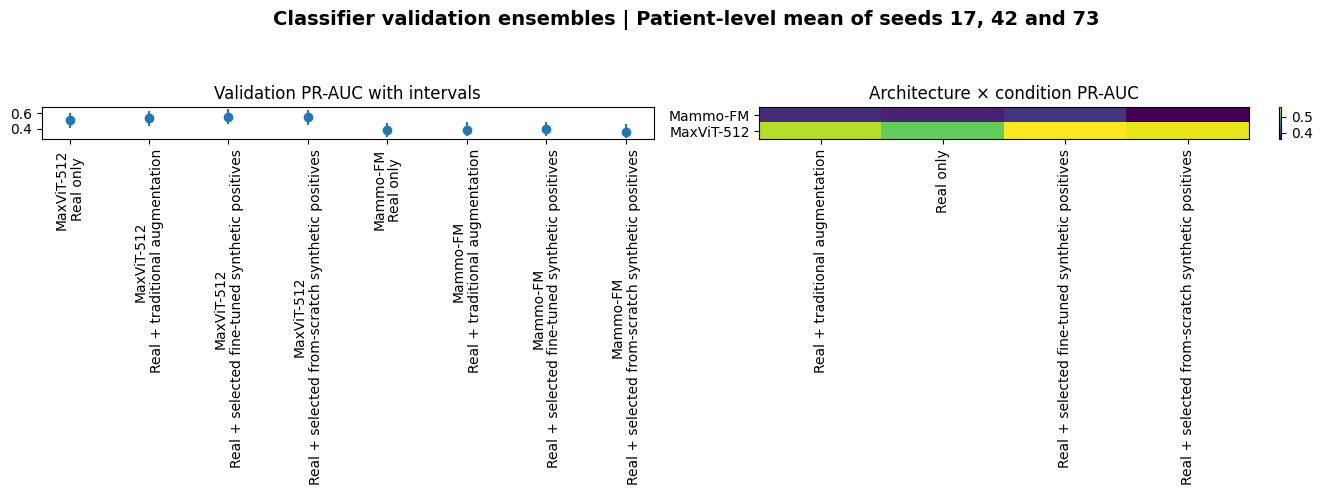

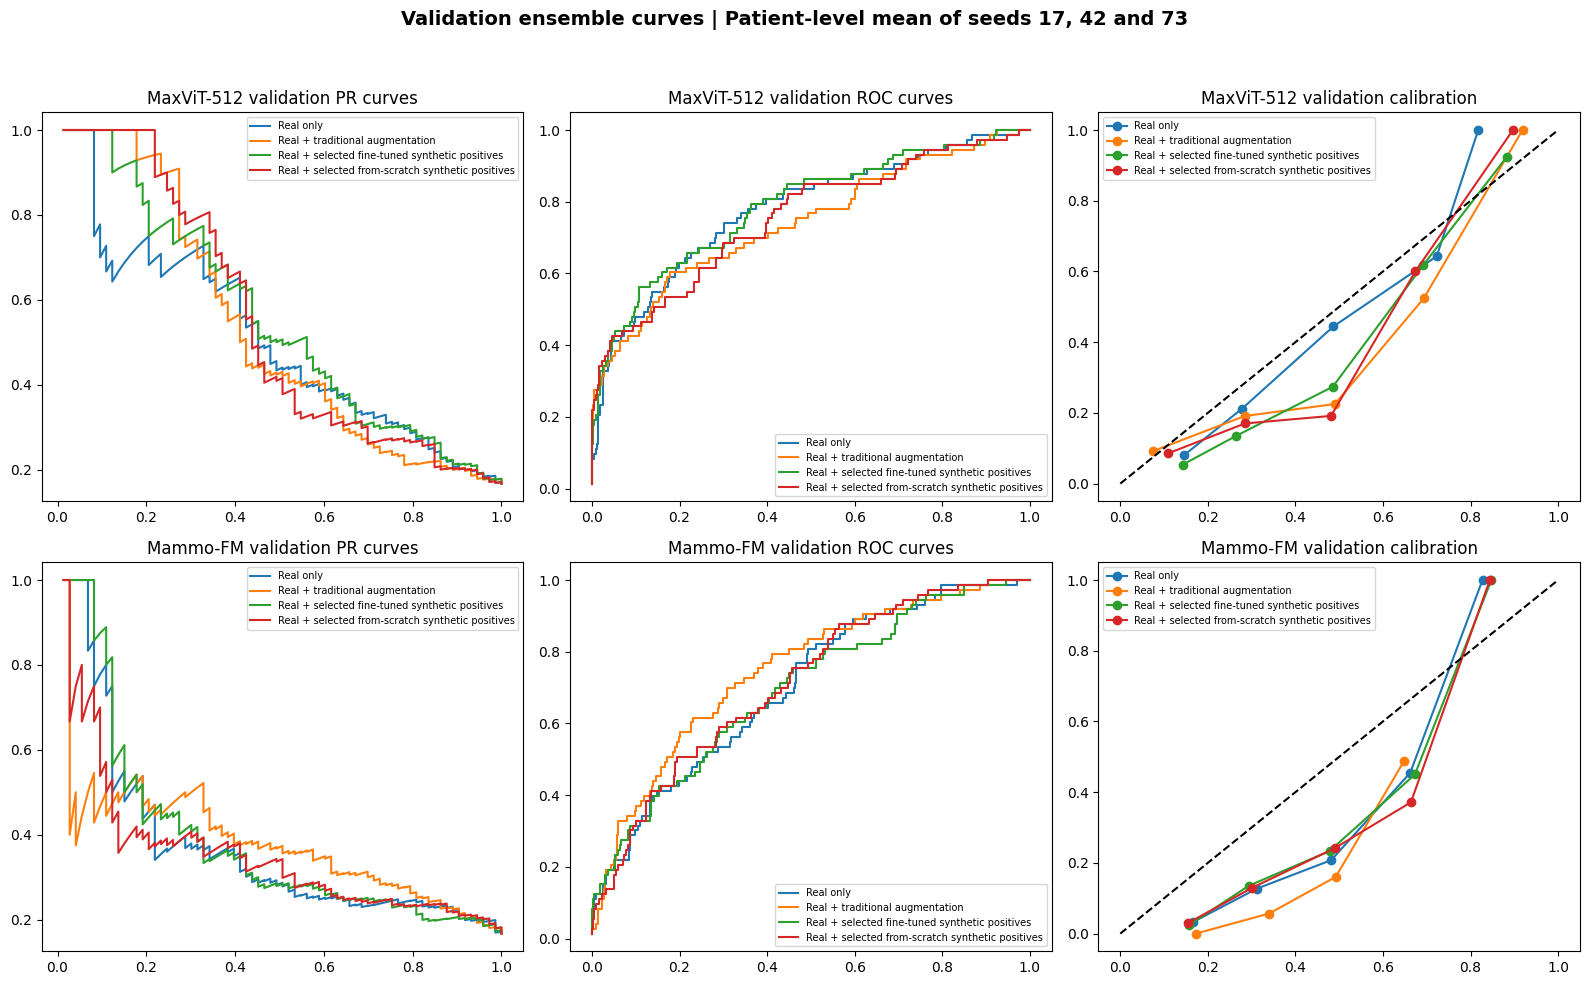

In [9]:
overview_figure = plot_ensemble_overview(ensembles) if ensembles is not None else None
curve_figure = plot_ensemble_curves(ROOT, ensembles) if ensembles is not None else None
(overview_figure, curve_figure) if overview_figure else 'Not yet evaluated — plots include PR-AUC intervals, ROC-AUC/Brier/ECE table, deltas vs real_only, seed mean/SD, heatmap, PR/ROC and calibration curves.'